In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style('whitegrid')

df = pd.read_csv('/content/Zomato_dts.csv',
                 encoding='latin-1',
                 usecols=range(17),
                 on_bad_lines='skip',
                 engine='python')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1732, 17)
Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
print("Raw rate column sample:")
print(df['rate'].unique()[:10])
df['rate'] = df['rate'].astype('str').str.replace('/5', '', regex=False)
df['rate'] = df['rate'].str.strip()
df['rate'] = df['rate'].replace(['NEW', '-', 'nan', 'None'], np.nan)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype('str')
    .str.replace(',', '', regex=False)
)
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce'
)
df.rename(columns={
    'approx_cost(for two people)': 'cost',
    'listed_in(type)'               : 'rest_type',
    'listed_in(city)'               : 'city'
}, inplace=True)

print("\nRate column after fix:", df['rate'].dtype)
print("Rate range:", df['rate'].min(), "to", df['rate'].max())
print("Cost column after fix:", df['cost'].dtype)

Raw rate column sample:
['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '\\nTop floor' '4.2/5'
 '3.9/5' '3.1/5']

Rate column after fix: float64
Rate range: 2.2 to 4.7
Cost column after fix: float64


In [ ]:
df = df.loc[:, ~df.columns.duplicated(keep='last')]

print("Columns now:", df.columns.tolist())
print("rest_type sample:", df['rest_type'].unique()[:5])
print("Shape:", df.shape)

Columns now: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'dish_liked', 'cuisines', 'cost', 'reviews_list', 'menu_item', 'rest_type', 'city']
rest_type sample: ['Buffet' 'Cafes' nan
 ' parking facility I could not locate. Staff can be little more local speaking '
 ' don\'t expect too much from this place.."")']
Shape: (1494, 16)


In [ ]:
# Clean missing values
df = df.dropna(subset=['rate'])
df['cost'] = df['cost'].fillna(df['cost'].median())
df['cuisines'] = df['cuisines'].fillna('Unknown')
df = df.drop_duplicates(subset=['name', 'location'])
df = df.reset_index(drop=True)

print("Final clean shape:", df.shape)
df.to_csv('zomato_clean.csv', index=False)
print("zomato_clean.csv saved! Ready for charts.")

Final clean shape: (1079, 16)
zomato_clean.csv saved! Ready for charts.


In [ ]:
print("Missing values before:\n", df.isnull().sum())

df = df.dropna(subset=['rate'])
df['cost'] = df['cost'].fillna(df['cost'].median())
df['cuisines'] = df['cuisines'].fillna('Unknown')
df = df.drop_duplicates(subset=['name', 'location'])
df = df.reset_index(drop=True)

print("\nMissing values after:\n", df.isnull().sum())
print("\nFinal dataset shape:", df.shape)
print("Ready for analysis!")

Missing values before:
 url               0
address           0
name              0
online_order      0
book_table        0
rate              0
votes             0
phone            13
location          0
dish_liked      567
cuisines          0
cost              0
reviews_list      0
menu_item        50
rest_type        50
city             50
dtype: int64

Missing values after:
 url               0
address           0
name              0
online_order      0
book_table        0
rate              0
votes             0
phone            13
location          0
dish_liked      567
cuisines          0
cost              0
reviews_list      0
menu_item        50
rest_type        50
city             50
dtype: int64

Final dataset shape: (1079, 16)
Ready for analysis!


In [ ]:
df.to_csv('zomato_clean.csv', index=False)
print("Saved: zomato_clean.csv")


Saved: zomato_clean.csv


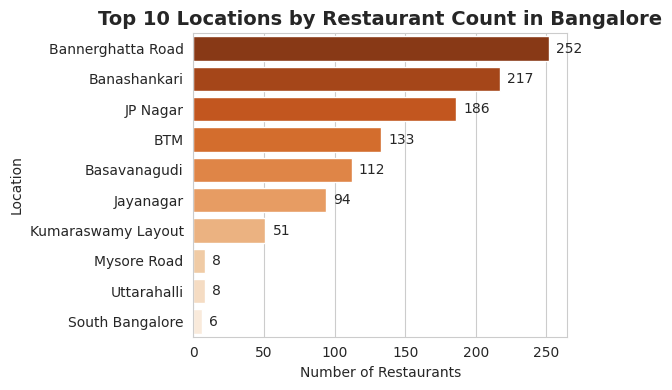

Top location: Bannerghatta Road with 252 restaurants


In [ ]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(6, 4))
bars = sns.barplot(x=top_locations.values, y=top_locations.index,
                    palette='Oranges_r')

for i, v in enumerate(top_locations.values):
    bars.text(v + 5, i, str(v), va='center', fontsize=10)

plt.title('Top 10 Locations by Restaurant Count in Bangalore',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

print("Top location:", top_locations.index[0],
      "with", top_locations.values[0], "restaurants")

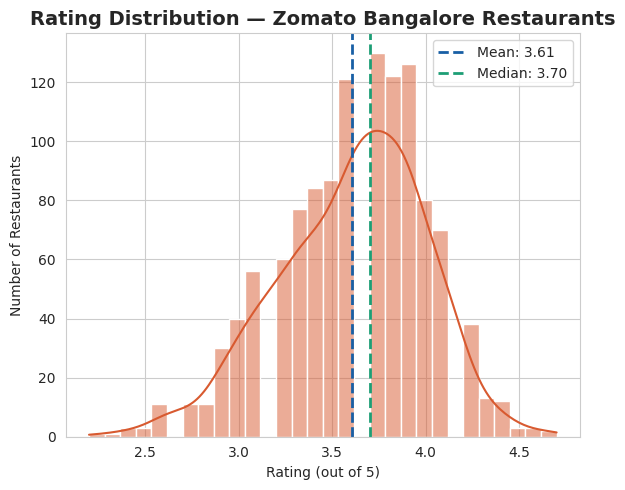

In [ ]:
plt.figure(figsize=(6, 5))
sns.histplot(df['rate'].dropna(), bins=30, kde=True,
             color='#D85A30', edgecolor='white')

mean_rate   = df['rate'].mean()
median_rate = df['rate'].median()
plt.axvline(mean_rate,   color='#185FA5', linestyle='--',
            linewidth=2, label=f'Mean: {mean_rate:.2f}')
plt.axvline(median_rate, color='#1D9E75', linestyle='--',
            linewidth=2, label=f'Median: {median_rate:.2f}')

plt.title('Rating Distribution — Zomato Bangalore Restaurants',
          fontsize=14, fontweight='bold')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Restaurants')
plt.legend()
plt.tight_layout()
plt.show()

Online order Yes — Median rating: 3.70
Online order No — Median rating: 3.50


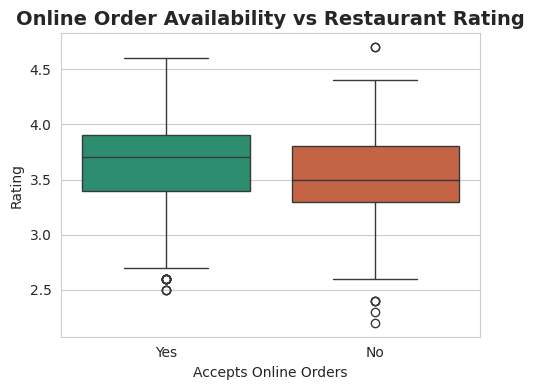

In [ ]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x='online_order', y='rate',
             palette={'Yes': '#1D9E75', 'No': '#D85A30'})

for grp in ['Yes', 'No']:
    med = df[df['online_order']==grp]['rate'].median()
    print(f"Online order {grp} — Median rating: {med:.2f}")

plt.title('Online Order Availability vs Restaurant Rating',
          fontsize=14, fontweight='bold')
plt.xlabel('Accepts Online Orders')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

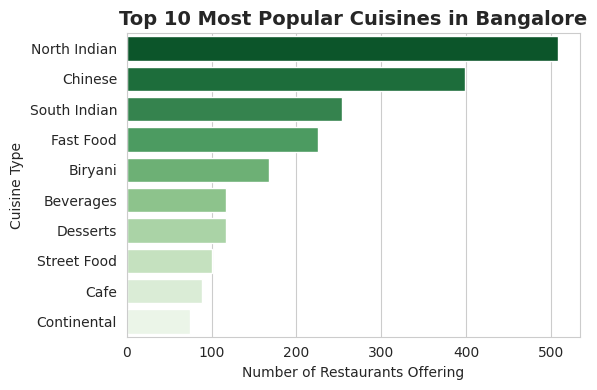

In [ ]:
cuisine_series = df['cuisines'].dropna().str.split(',').explode()
cuisine_series = cuisine_series.str.strip()  # remove extra spaces
top_cuisines = cuisine_series.value_counts().head(10)
plt.figure(figsize=(6, 4))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index,
            palette='Greens_r')

plt.title('Top 10 Most Popular Cuisines in Bangalore',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants Offering')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.show()

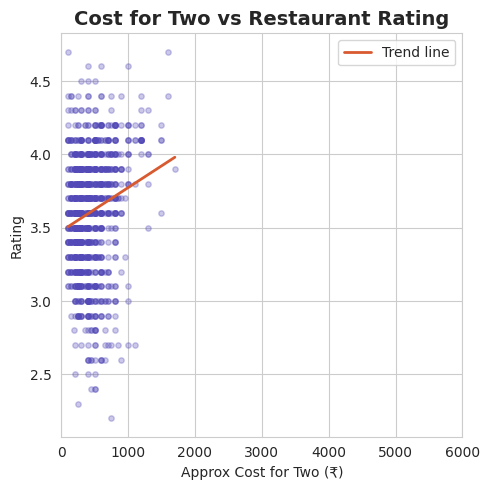

Correlation between cost and rating: 0.185


In [ ]:
plt.figure(figsize=(5, 5))
plt.scatter(df['cost'], df['rate'],
            alpha=0.3, color='#534AB7', s=15)

from numpy.polynomial.polynomial import polyfit
clean = df[['cost', 'rate']].dropna()
b, m = polyfit(clean['cost'], clean['rate'], 1)
plt.plot(clean['cost'].sort_values(),
         b + m * clean['cost'].sort_values(),
         color='#D85A30', linewidth=2, label='Trend line')

plt.title('Cost for Two vs Restaurant Rating',
          fontsize=14, fontweight='bold')
plt.xlabel('Approx Cost for Two (₹)')
plt.ylabel('Rating')
plt.xlim(0, 6000)
plt.legend()
plt.tight_layout()
plt.show()

corr = df[['cost', 'rate']].corr().iloc[0,1]
print(f"Correlation between cost and rating: {corr:.3f}")

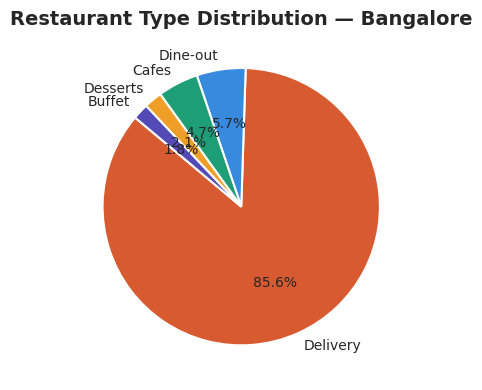


Phase 1 complete!
Clean dataset saved: 1195 restaurants ready for SQL


In [ ]:
type_counts = df['rest_type'].value_counts().head(7)

plt.figure(figsize=(4, 4))
colors = ['#D85A30', '#378ADD', '#1D9E75',
          '#EF9F27', '#534AB7', '#639922', '#888780']

plt.pie(type_counts.values,
        labels=type_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

plt.title('Restaurant Type Distribution — Bangalore',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
df.to_csv('zomato_clean.csv', index=False)
print(f"Clean dataset saved: {df.shape[0]} restaurants ready for SQL")

In [ ]:
import sqlite3
import pandas as pd
df = pd.read_csv('zomato_clean.csv')
conn = sqlite3.connect('zomato.db')
df.to_sql('restaurants', conn, if_exists='replace', index=False)

print("Database created!")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

Database created!
Total rows: 1079
Columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'dish_liked', 'cuisines', 'cost', 'reviews_list', 'menu_item', 'rest_type', 'city']


In [ ]:
# Q1 — Top 10 locations by restaurant count
q1 = """
SELECT location,
       COUNT(*) AS total_restaurants,
       ROUND(AVG(rate), 2) AS avg_rating
FROM restaurants
GROUP BY location
ORDER BY total_restaurants DESC
LIMIT 10
"""
print("Q1 — Top 10 Locations:")
print(pd.read_sql_query(q1, conn).to_string(index=False))
q2 = """
SELECT online_order,
       COUNT(*) AS total,
       ROUND(AVG(rate), 2) AS avg_rating,
       ROUND(AVG(cost), 0) AS avg_cost
FROM restaurants
GROUP BY online_order
ORDER BY avg_rating DESC
"""
print("\nQ2 — Online Order vs Rating:")
print(pd.read_sql_query(q2, conn).to_string(index=False))

# Q3 — Top 10 expensive locations by avg cost
q3 = """
SELECT location,
       ROUND(AVG(cost), 0) AS avg_cost_for_two,
       COUNT(*) AS restaurants,
       ROUND(AVG(rate), 2) AS avg_rating
FROM restaurants
GROUP BY location
HAVING COUNT(*) > 20
ORDER BY avg_cost_for_two DESC
LIMIT 10
"""
print("\nQ3 — Most Expensive Locations:")
print(pd.read_sql_query(q3, conn).to_string(index=False))

Q1 — Top 10 Locations:
          location  total_restaurants  avg_rating
 Bannerghatta Road                252        3.51
      Banashankari                217        3.63
          JP Nagar                186        3.67
               BTM                133        3.61
      Basavanagudi                112        3.71
         Jayanagar                 94        3.81
Kumaraswamy Layout                 51        3.49
       Uttarahalli                  8        3.50
       Mysore Road                  8        3.64
   South Bangalore                  6        3.55

Q2 — Online Order vs Rating:
online_order  total  avg_rating  avg_cost
         Yes    856        3.64     439.0
          No    223        3.54     427.0

Q3 — Most Expensive Locations:
          location  avg_cost_for_two  restaurants  avg_rating
         Jayanagar             528.0           94        3.81
          JP Nagar             488.0          186        3.67
 Bannerghatta Road             469.0          252    

In [ ]:
# Q4 — Top 5 restaurant types by avg rating (min 50 restaurants)
q4 = """
SELECT rest_type,
       COUNT(*) AS total,
       ROUND(AVG(rate), 2) AS avg_rating,
       ROUND(AVG(cost), 0) AS avg_cost
FROM restaurants
GROUP BY rest_type
HAVING COUNT(*) > 50
ORDER BY avg_rating DESC
LIMIT 5
"""
print("Q4 — Best Rated Restaurant Types:")
print(pd.read_sql_query(q4, conn).to_string(index=False))

Q4 — Best Rated Restaurant Types:
rest_type  total  avg_rating  avg_cost
    Cafes     54        3.69     561.0
 Dine-out     65        3.63     349.0
 Delivery    874        3.62     418.0


In [ ]:
# Q5 — Rating category breakdown using CASE WHEN
q5 = """
SELECT
    CASE
        WHEN rate >= 4.5 THEN 'Excellent (4.5+)'
        WHEN rate >= 4.0 THEN 'Very Good (4.0-4.5)'
        WHEN rate >= 3.5 THEN 'Good (3.5-4.0)'
        WHEN rate >= 3.0 THEN 'Average (3.0-3.5)'
        ELSE 'Below Average (<3.0)'
    END AS rating_category,
    COUNT(*) AS restaurant_count,
    ROUND(AVG(cost), 0) AS avg_cost,
    ROUND(AVG(votes), 0) AS avg_votes
FROM restaurants
GROUP BY rating_category
ORDER BY restaurant_count DESC
"""
print("\nQ5 — Rating Category Breakdown:")
print(pd.read_sql_query(q5, conn).to_string(index=False))


Q5 — Rating Category Breakdown:
     rating_category  restaurant_count  avg_cost  avg_votes
      Good (3.5-4.0)               530     413.0      118.0
   Average (3.0-3.5)               277     367.0       43.0
 Very Good (4.0-4.5)               205     570.0      611.0
Below Average (<3.0)                59     491.0      126.0
    Excellent (4.5+)                 8     613.0     1196.0


In [ ]:
# Q6 — Table booking impact on rating and cost
q6 = """
SELECT book_table,
       COUNT(*) AS total,
       ROUND(AVG(rate), 2) AS avg_rating,
       ROUND(AVG(cost), 0) AS avg_cost,
       ROUND(AVG(votes), 0) AS avg_votes
FROM restaurants
GROUP BY book_table
ORDER BY avg_rating DESC
"""
print("\nQ6 — Table Booking vs Rating:")
print(pd.read_sql_query(q6, conn).to_string(index=False))


Q6 — Table Booking vs Rating:
book_table  total  avg_rating  avg_cost  avg_votes
       Yes     71         4.0     932.0      941.0
        No   1008         3.6     401.0      149.0


In [ ]:
# Q7 — Locations where avg rating is ABOVE city average (subquery)
q7 = """
SELECT location,
       ROUND(AVG(rate), 2) AS avg_rating,
       COUNT(*) AS total_restaurants
FROM restaurants
GROUP BY location
HAVING AVG(rate) > (SELECT AVG(rate) FROM restaurants)
ORDER BY avg_rating DESC
LIMIT 10
"""
print("Q7 — Locations Above City Average Rating:")
print(pd.read_sql_query(q7, conn).to_string(index=False))

Q7 — Locations Above City Average Rating:
            location  avg_rating  total_restaurants
Rajarajeshwari Nagar        3.85                  2
           Jayanagar        3.81                 94
        Basavanagudi        3.71                112
         Vijay Nagar        3.68                  4
            JP Nagar        3.67                186
         Mysore Road        3.64                  8
        Banashankari        3.63                217


In [ ]:
# Q8 — High votes but LOW rating (overrated/disappointing restaurants)
q8 = """
SELECT name, location, rate, votes, cost
FROM restaurants
WHERE votes > (SELECT AVG(votes) FROM restaurants)
  AND rate < (SELECT AVG(rate) FROM restaurants)
ORDER BY votes DESC
LIMIT 10
"""
print("\nQ8 — Popular but Low-Rated Restaurants:")
print(pd.read_sql_query(q8, conn).to_string(index=False))


Q8 — Popular but Low-Rated Restaurants:
                    name           location  rate  votes  cost
Hyderabad Biryaani House  Bannerghatta Road   3.6    794 550.0
               FreshMenu  Bannerghatta Road   3.3    628 450.0
        Marwa Restaurant  Bannerghatta Road   3.5    551 600.0
           Shanthi Sagar           JP Nagar   3.6    518 400.0
             Olive - Era Kumaraswamy Layout   3.3    511 550.0
              Foodiction       Banashankari   2.8    506 500.0
             Apna Punjab                BTM   3.6    474 450.0
           Crunch Pizzas                BTM   2.6    473 600.0
         Abhiruchi Hotel  Bannerghatta Road   3.3    455 550.0
         Punjabi Raswada          Jayanagar   3.5    431 800.0


In [ ]:
# Q9 — Avg cost of restaurants serving above-average voted cuisines
q9 = """
SELECT rest_type,
       ROUND(AVG(cost), 0) AS avg_cost,
       ROUND(AVG(rate), 2) AS avg_rating,
       COUNT(*) AS count
FROM restaurants
WHERE votes > (SELECT AVG(votes) FROM restaurants)
GROUP BY rest_type
ORDER BY avg_cost DESC
LIMIT 8
"""
print("\nQ9 — Cost of High-Vote Restaurant Types:")
print(pd.read_sql_query(q9, conn).to_string(index=False))


Q9 — Cost of High-Vote Restaurant Types:
rest_type  avg_cost  avg_rating  count
   Buffet     915.0        4.05     13
     None     702.0        3.78     26
 Delivery     598.0        3.91    197
 Dine-out     588.0        4.00      8
    Cafes     588.0        4.13      8
 Desserts     150.0        4.40      1


In [ ]:
# Q10 — CTE: find premium locations (high cost + high rating)
q10 = """
WITH location_stats AS (
    SELECT
        location,
        ROUND(AVG(rate), 2)  AS avg_rating,
        ROUND(AVG(cost), 0)  AS avg_cost,
        COUNT(*)             AS total
    FROM restaurants
    GROUP BY location
    HAVING COUNT(*) > 15
),
city_avg AS (
    SELECT
        AVG(avg_rating) AS city_avg_rating,
        AVG(avg_cost)   AS city_avg_cost
    FROM location_stats
)
SELECT ls.location, ls.avg_rating, ls.avg_cost, ls.total
FROM location_stats ls, city_avg ca
WHERE ls.avg_rating > ca.city_avg_rating
  AND ls.avg_cost   > ca.city_avg_cost
ORDER BY ls.avg_rating DESC
"""

# Q11 — CTE: budget gems (low cost but high rating)
q11 = """
WITH stats AS (
    SELECT
        location,
        ROUND(AVG(rate), 2) AS avg_rating,
        ROUND(AVG(cost), 0) AS avg_cost,
        COUNT(*)            AS total
    FROM restaurants
    GROUP BY location
    HAVING COUNT(*) > 15
)
SELECT location, avg_rating, avg_cost, total
FROM stats
WHERE avg_cost   < 400
  AND avg_rating > 3.8
ORDER BY avg_rating DESC
LIMIT 8
"""
print("\nQ11 — Budget Hidden Gems (CTE):")
print(pd.read_sql_query(q11, conn).to_string(index=False))
# Q12 — CTE: online vs offline performance by location
q12 = """
WITH online AS (
    SELECT location,
           ROUND(AVG(rate), 2) AS online_avg_rate,
           COUNT(*)            AS online_count
    FROM restaurants
    WHERE online_order = 'Yes'
    GROUP BY location
),
offline AS (
    SELECT location,
           ROUND(AVG(rate), 2) AS offline_avg_rate,
           COUNT(*)            AS offline_count
    FROM restaurants
    WHERE online_order = 'No'
    GROUP BY location
)
SELECT o.location,
       o.online_avg_rate,
       f.offline_avg_rate,
       ROUND(o.online_avg_rate - f.offline_avg_rate, 2) AS rating_diff
FROM online o
JOIN offline f ON o.location = f.location
ORDER BY rating_diff DESC
LIMIT 10
"""
print("\nQ12 — Online vs Offline Rating Gap by Location (CTE + JOIN):")
print(pd.read_sql_query(q12, conn).to_string(index=False))


Q11 — Budget Hidden Gems (CTE):
Empty DataFrame
Columns: [location, avg_rating, avg_cost, total]
Index: []

Q12 — Online vs Offline Rating Gap by Location (CTE + JOIN):
         location  online_avg_rate  offline_avg_rate  rating_diff
              BTM             3.62              3.25         0.37
        Jayanagar             3.82              3.63         0.19
Bannerghatta Road             3.56              3.38         0.18
      Mysore Road             3.73              3.55         0.18
     Banashankari             3.68              3.57         0.11
     Basavanagudi             3.69              3.73        -0.04
         JP Nagar             3.67              3.80        -0.13
  South Bangalore             3.50              3.80        -0.30


In [ ]:
# Q13 — RANK restaurants within each location by rating
q13 = """
SELECT name, location, rate, votes, cost,
       RANK() OVER (
           PARTITION BY location
           ORDER BY rate DESC, votes DESC
       ) AS rank_in_location
FROM restaurants
WHERE rate IS NOT NULL
QUALIFY rank_in_location <= 3
"""
q13 = """
SELECT * FROM (
    SELECT name, location, rate, votes,
           RANK() OVER (
               PARTITION BY location
               ORDER BY rate DESC, votes DESC
           ) AS rank_in_location
    FROM restaurants
    WHERE rate IS NOT NULL
) ranked
WHERE rank_in_location <= 3
ORDER BY location, rank_in_location
LIMIT 20
"""
print("Q13 — Top 3 Restaurants per Location (RANK + PARTITION BY):")
print(pd.read_sql_query(q13, conn).to_string(index=False))
# Q14 — Running average rating by location using AVG window function
q14 = """
SELECT name, location, rate,
       ROUND(AVG(rate) OVER (
           PARTITION BY location
           ORDER BY votes DESC
           ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
       ), 2) AS running_avg_rating
FROM restaurants
WHERE rate IS NOT NULL
ORDER BY location, votes DESC
LIMIT 20
"""
print("\nQ14 — Running Avg Rating by Location (Window AVG):")
print(pd.read_sql_query(q14, conn).to_string(index=False))

# Q15 — ROW_NUMBER to find most voted restaurant per rest_type
q15 = """
SELECT * FROM (
    SELECT name, rest_type, votes, rate, cost,
           ROW_NUMBER() OVER (
               PARTITION BY rest_type
               ORDER BY votes DESC
           ) AS row_num
    FROM restaurants
    WHERE rate IS NOT NULL
) t
WHERE row_num = 1
ORDER BY votes DESC
LIMIT 10
"""
print("\nQ15 — Most Voted Restaurant per Type (ROW_NUMBER):")
print(pd.read_sql_query(q15, conn).to_string(index=False))


conn.close()
print("\nAll 15 queries done! Phase 2 complete!")

Q13 — Top 3 Restaurants per Location (RANK + PARTITION BY):
                    name          location  rate  votes  rank_in_location
                 eat.fit               BTM   4.5   1178                 1
       XO Belgian Waffle               BTM   4.5    549                 2
           BANGALORE BOX               BTM   4.2    611                 3
            Taaza Thindi      Banashankari   4.7    651                 1
                  Onesta      Banashankari   4.6   2556                 2
           Poonam Sweets      Banashankari   4.4    356                 3
                Galito's Bannerghatta Road   4.6    404                 1
       Deja Vu Resto Bar Bannerghatta Road   4.4   2487                 2
                 Chavadi Bannerghatta Road   4.4   2233                 3
        Vidyarthi Bhavan      Basavanagudi   4.4   4460                 1
           South Kitchen      Basavanagudi   4.3    275                 2
        Puliyogare Point      Basavanagudi   4.2    